In [7]:
import icu_sepsis

In [19]:
# implement a data collection procedure on the RTBGym environment

# import SCOPE-RL modules
from scope_rl.dataset import SyntheticDataset
from scope_rl.policy import EpsilonGreedyHead
# import d3rlpy algorithms
from d3rlpy.algos import DoubleDQNConfig
from d3rlpy.dataset import create_fifo_replay_buffer
from d3rlpy.algos import ConstantEpsilonGreedy
# import rtbgym and gym
import rtbgym
import gymnasium as gym
import torch
import numpy as np
# random state
random_state = 12345
device = "cuda:0" if torch.cuda.is_available() else "cpu"

# (0) Setup environment
class OneHotObservation(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        n = env.observation_space.n
        self.observation_space = gym.spaces.Box(
            low=0, high=1, shape=(n,), dtype=np.float32
        )

    def observation(self, obs):
        one_hot = np.zeros(self.observation_space.shape[0], dtype=np.float32)
        one_hot[obs] = 1.0
        return one_hot
env = gym.make("Sepsis/ICU-Sepsis-v2")
env = OneHotObservation(env)


# (1) Learn a baseline policy in an online environment (using d3rlpy)
# initialize the algorithm
ddqn = DoubleDQNConfig().create(device=device)
# train an online policy
# this takes about 5min to compute
ddqn.fit_online(
    env,
    buffer=create_fifo_replay_buffer(limit=10000, env=env),
    explorer=ConstantEpsilonGreedy(epsilon=0.3),
    n_steps=10000,
    n_steps_per_epoch=1000,
    update_start_step=1000,
)

# (2) Generate a logged dataset
# convert the ddqn policy into a stochastic behavior policy
behavior_policy = EpsilonGreedyHead(
    ddqn,
    n_actions=int(env.action_space.n),
    epsilon=0.3,
    name="ddqn_epsilon_0.3",
    random_state=random_state,
)
# initialize the dataset class
dataset = SyntheticDataset(
    env=env,
    max_episode_steps=20,
)
# the behavior policy collects some logged data
train_logged_dataset = dataset.obtain_episodes(
  behavior_policies=behavior_policy,
  n_trajectories=10000,
  random_state=random_state,
)
test_logged_dataset = dataset.obtain_episodes(
  behavior_policies=behavior_policy,
  n_trajectories=10000,
  random_state=random_state + 1,
)

2025-10-29 16:39.48 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[()]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(716,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[[1]])
2025-10-29 16:39.48 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-10-29 16:39.48 [info     ] Action size has been automatically determined. action_size=25
2025-10-29 16:39.48 [debug    ] Building model...             
2025-10-29 16:39.48 [debug    ] Model has been built.         
2025-10-29 16:39.48 [info     ] Directory is created at d3rlpy_logs/DoubleDQN_online_20251029163948
2025-10-29 16:39.48 [info     ] Parameters                     params={'observation_shape': [716], 'action_size': 25, 'config': {'type': 'double_dqn', 'params': {'batch_size': 32, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'non

  9%|▉         | 902/10000 [00:00<00:04, 2208.87it/s]

2025-10-29 16:39.48 [info     ] Model parameters are saved to d3rlpy_logs/DoubleDQN_online_20251029163948/model_1000.d3
2025-10-29 16:39.48 [info     ] DoubleDQN_online_20251029163948: epoch=1 step=1000 epoch=1 metrics={'time_inference': 0.0003624365329742432, 'time_environment_step': 5.6110382080078124e-05, 'time_step': 0.00044468879699707033, 'rollout_return': 0.7962962962962963} step=1000


 20%|█▉        | 1985/10000 [00:04<00:30, 264.49it/s]

2025-10-29 16:39.52 [info     ] Model parameters are saved to d3rlpy_logs/DoubleDQN_online_20251029163948/model_2000.d3
2025-10-29 16:39.52 [info     ] DoubleDQN_online_20251029163948: epoch=2 step=2000 epoch=2 metrics={'time_inference': 0.00044431042671203615, 'time_environment_step': 7.106471061706543e-05, 'time_sample_batch': 0.0004976165294647217, 'time_algorithm_update': 0.0027218122482299805, 'loss': 0.03278142176719848, 'time_step': 0.0037811665534973143, 'rollout_return': 0.8} step=2000


...

2025-10-29 16:40.20 [info     ] Model parameters are saved to d3rlpy_logs/DoubleDQN_online_20251029163948/model_9000.d3
2025-10-29 16:40.20 [info     ] DoubleDQN_online_20251029163948: epoch=9 step=9000 epoch=9 metrics={'time_inference': 0.00045453882217407225, 'time_environment_step': 7.158613204956055e-05, 'time_sample_batch': 0.0005140349864959716, 'time_algorithm_update': 0.002778902769088745, 'loss': 0.03188840642455034, 'time_step': 0.003864826440811157, 'rollout_return': 0.6764705882352942} step=9000


100%|█████████▉| 9977/10000 [00:35<00:00, 251.58it/s]

2025-10-29 16:40.24 [info     ] Model parameters are saved to d3rlpy_logs/DoubleDQN_online_20251029163948/model_10000.d3
2025-10-29 16:40.24 [info     ] DoubleDQN_online_20251029163948: epoch=10 step=10000 epoch=10 metrics={'time_inference': 0.00046169567108154296, 'time_environment_step': 7.231020927429199e-05, 'time_sample_batch': 0.0005184919834136963, 'time_algorithm_update': 0.0028123605251312257, 'loss': 0.027562941601965575, 'time_step': 0.003911422252655029, 'rollout_return': 0.7981651376146789} step=10000


100%|██████████| 10000/10000 [00:35<00:00, 280.35it/s]


ValueError: env must be a child class of gym.Env

In [5]:
# implement an offline RL procedure using SCOPE-RL and d3rlpy

# import d3rlpy algorithms
from d3rlpy.dataset import MDPDataset
from d3rlpy.algos import DiscreteCQLConfig

# (3) Learning a new policy from offline logged data (using d3rlpy)
# convert the logged dataset into d3rlpy's dataset format
offlinerl_dataset = MDPDataset(
    observations=train_logged_dataset["state"],
    actions=train_logged_dataset["action"],
    rewards=train_logged_dataset["reward"],
    terminals=train_logged_dataset["done"],
)
# initialize the algorithm
cql = DiscreteCQLConfig().create(device=device)
# train an offline policy
cql.fit(
    offlinerl_dataset,
    n_steps=10000,
)

2025-10-29 16:06.17 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float64')], shape=[(7,)]) reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)])
2025-10-29 16:06.17 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-10-29 16:06.17 [info     ] Action size has been automatically determined. action_size=10
2025-10-29 16:06.17 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float64')], shape=[(7,)]), action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=10)
2025-10-29 16:06.17 [debug    ] Building models...            
2025-10-29 16:06.17 [debug    ] Models have been built.       
2025-10-29 16:06.17 [info  

Epoch 1/1: 100%|██████████| 10000/10000 [00:44<00:00, 224.32it/s, loss=65, td_loss=60.7, conservative_loss=4.31] 

2025-10-29 16:07.02 [info     ] DiscreteCQL_20251029160617: epoch=1 step=10000 epoch=1 metrics={'time_sample_batch': 0.0005203861474990845, 'time_algorithm_update': 0.0037354859113693235, 'loss': 64.99245420713424, 'td_loss': 60.686781540632246, 'conservative_loss': 4.3056726761698725, 'time_step': 0.004421780514717102} step=10000


2025-10-29 16:07.02 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteCQL_20251029160617/model_10000.d3


[(1,
  {'time_sample_batch': 0.0005203861474990845,
   'time_algorithm_update': 0.0037354859113693235,
   'loss': 64.99245420713424,
   'td_loss': 60.686781540632246,
   'conservative_loss': 4.3056726761698725,
   'time_step': 0.004421780514717102})]

2025-10-29 16:07.10 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float64')], shape=[(7,)]) reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)])
2025-10-29 16:07.10 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.DISCRETE: 2>
2025-10-29 16:07.10 [info     ] Action size has been automatically determined. action_size=10


[fit FQE model]:   0%|          | 0/3 [00:00<?, ?it/s]

2025-10-29 16:07.10 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float64')], shape=[(7,)]), action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=10)
2025-10-29 16:07.10 [debug    ] Building models...            
2025-10-29 16:07.10 [debug    ] Models have been built.       
2025-10-29 16:07.10 [info     ] Directory is created at d3rlpy_logs/DiscreteFQE_20251029160710
2025-10-29 16:07.10 [info     ] Parameters                     params={'observation_shape': [7], 'action_size': 10, 'config': {'type': 'fqe', 'params': {'batch_size': 100, 'gamma': 1.0, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'learning_rate': 0.0001, 'optim_factory': {'type': 'adam', 'params

Epoch 1/1: 100%|██████████| 10000/10000 [00:39<00:00, 250.72it/s, loss=9.82]


2025-10-29 16:07.50 [info     ] DiscreteFQE_20251029160710: epoch=1 step=10000 epoch=1 metrics={'time_sample_batch': 0.0013196420431137086, 'time_algorithm_update': 0.002425911283493042, 'loss': 9.809157715579868, 'time_step': 0.003928229928016663} step=10000
2025-10-29 16:07.50 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteFQE_20251029160710/model_10000.d3


...

2025-10-29 16:08.30 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float64')], shape=[(7,)]), action_signature=Signature(dtype=[dtype('int64')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)]), action_space=<ActionSpace.DISCRETE: 2>, action_size=10)
2025-10-29 16:08.30 [debug    ] Building models...            
2025-10-29 16:08.30 [debug    ] Models have been built.       
2025-10-29 16:08.30 [info     ] Directory is created at d3rlpy_logs/DiscreteFQE_20251029160830
2025-10-29 16:08.30 [info     ] Parameters                     params={'observation_shape': [7], 'action_size': 10, 'config': {'type': 'fqe', 'params': {'batch_size': 100, 'gamma': 1.0, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'learning_rate': 0.0001, 'optim_factory': {'type': 'adam', 'params

Epoch 1/1: 100%|██████████| 10000/10000 [00:38<00:00, 257.63it/s, loss=4.51]

2025-10-29 16:09.09 [info     ] DiscreteFQE_20251029160830: epoch=1 step=10000 epoch=1 metrics={'time_sample_batch': 0.0013071436405181884, 'time_algorithm_update': 0.0023661625623703003, 'loss': 4.503457342651487, 'time_step': 0.003831539511680603} step=10000


2025-10-29 16:09.09 [info     ] Model parameters are saved to d3rlpy_logs/DiscreteFQE_20251029160830/model_10000.d3


[collect input data: eval_policy]: 100%|██████████| 3/3 [00:03<00:00,  1.32s/it]


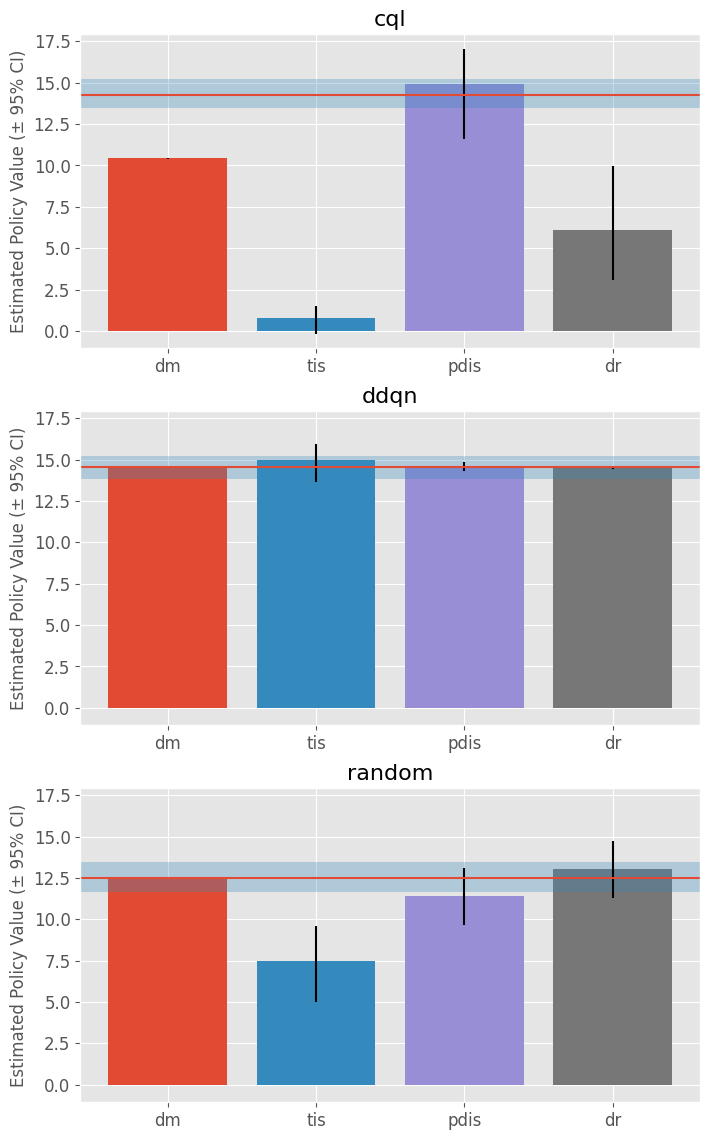

In [6]:
from scope_rl.policy import EpsilonGreedyHead
# import SCOPE-RL modules
from scope_rl.ope import CreateOPEInput
from scope_rl.ope import OffPolicyEvaluation as OPE
from scope_rl.ope.discrete import DirectMethod as DM
from scope_rl.ope.discrete import TrajectoryWiseImportanceSampling as TIS
from scope_rl.ope.discrete import PerDecisionImportanceSampling as PDIS
from scope_rl.ope.discrete import DoublyRobust as DR

# (4) Evaluate the learned policy in an offline manner
# we compare ddqn, cql, and random policy
cql_ = EpsilonGreedyHead(
    base_policy=cql,
    n_actions=env.action_space.n,
    name="cql",
    epsilon=0.0,
    random_state=random_state,
)
ddqn_ = EpsilonGreedyHead(
    base_policy=ddqn,
    n_actions=env.action_space.n,
    name="ddqn",
    epsilon=0.0,
    random_state=random_state,
)
random_ = EpsilonGreedyHead(
    base_policy=ddqn,
    n_actions=env.action_space.n,
    name="random",
    epsilon=1.0,
    random_state=random_state,
)
evaluation_policies = [cql_, ddqn_, random_]
# create input for the OPE class
prep = CreateOPEInput(
    env=env,
)
input_dict = prep.obtain_whole_inputs(
    logged_dataset=test_logged_dataset,
    evaluation_policies=evaluation_policies,
    require_value_prediction=True,
    n_trajectories_on_policy_evaluation=100,
    random_state=random_state,
)
# initialize the OPE class
ope = OPE(
    logged_dataset=test_logged_dataset,
    ope_estimators=[DM(), TIS(), PDIS(), DR()],
)
# perform OPE and visualize the result
ope.visualize_off_policy_estimates(
    input_dict,
    random_state=random_state,
    sharey=True,
)